# softmax heatmap plot (Julia)

- `OUTDIR` 環境変数で結果ディレクトリを指定
- 指定がない場合は `results/latest_softmax_heatmap` を参照

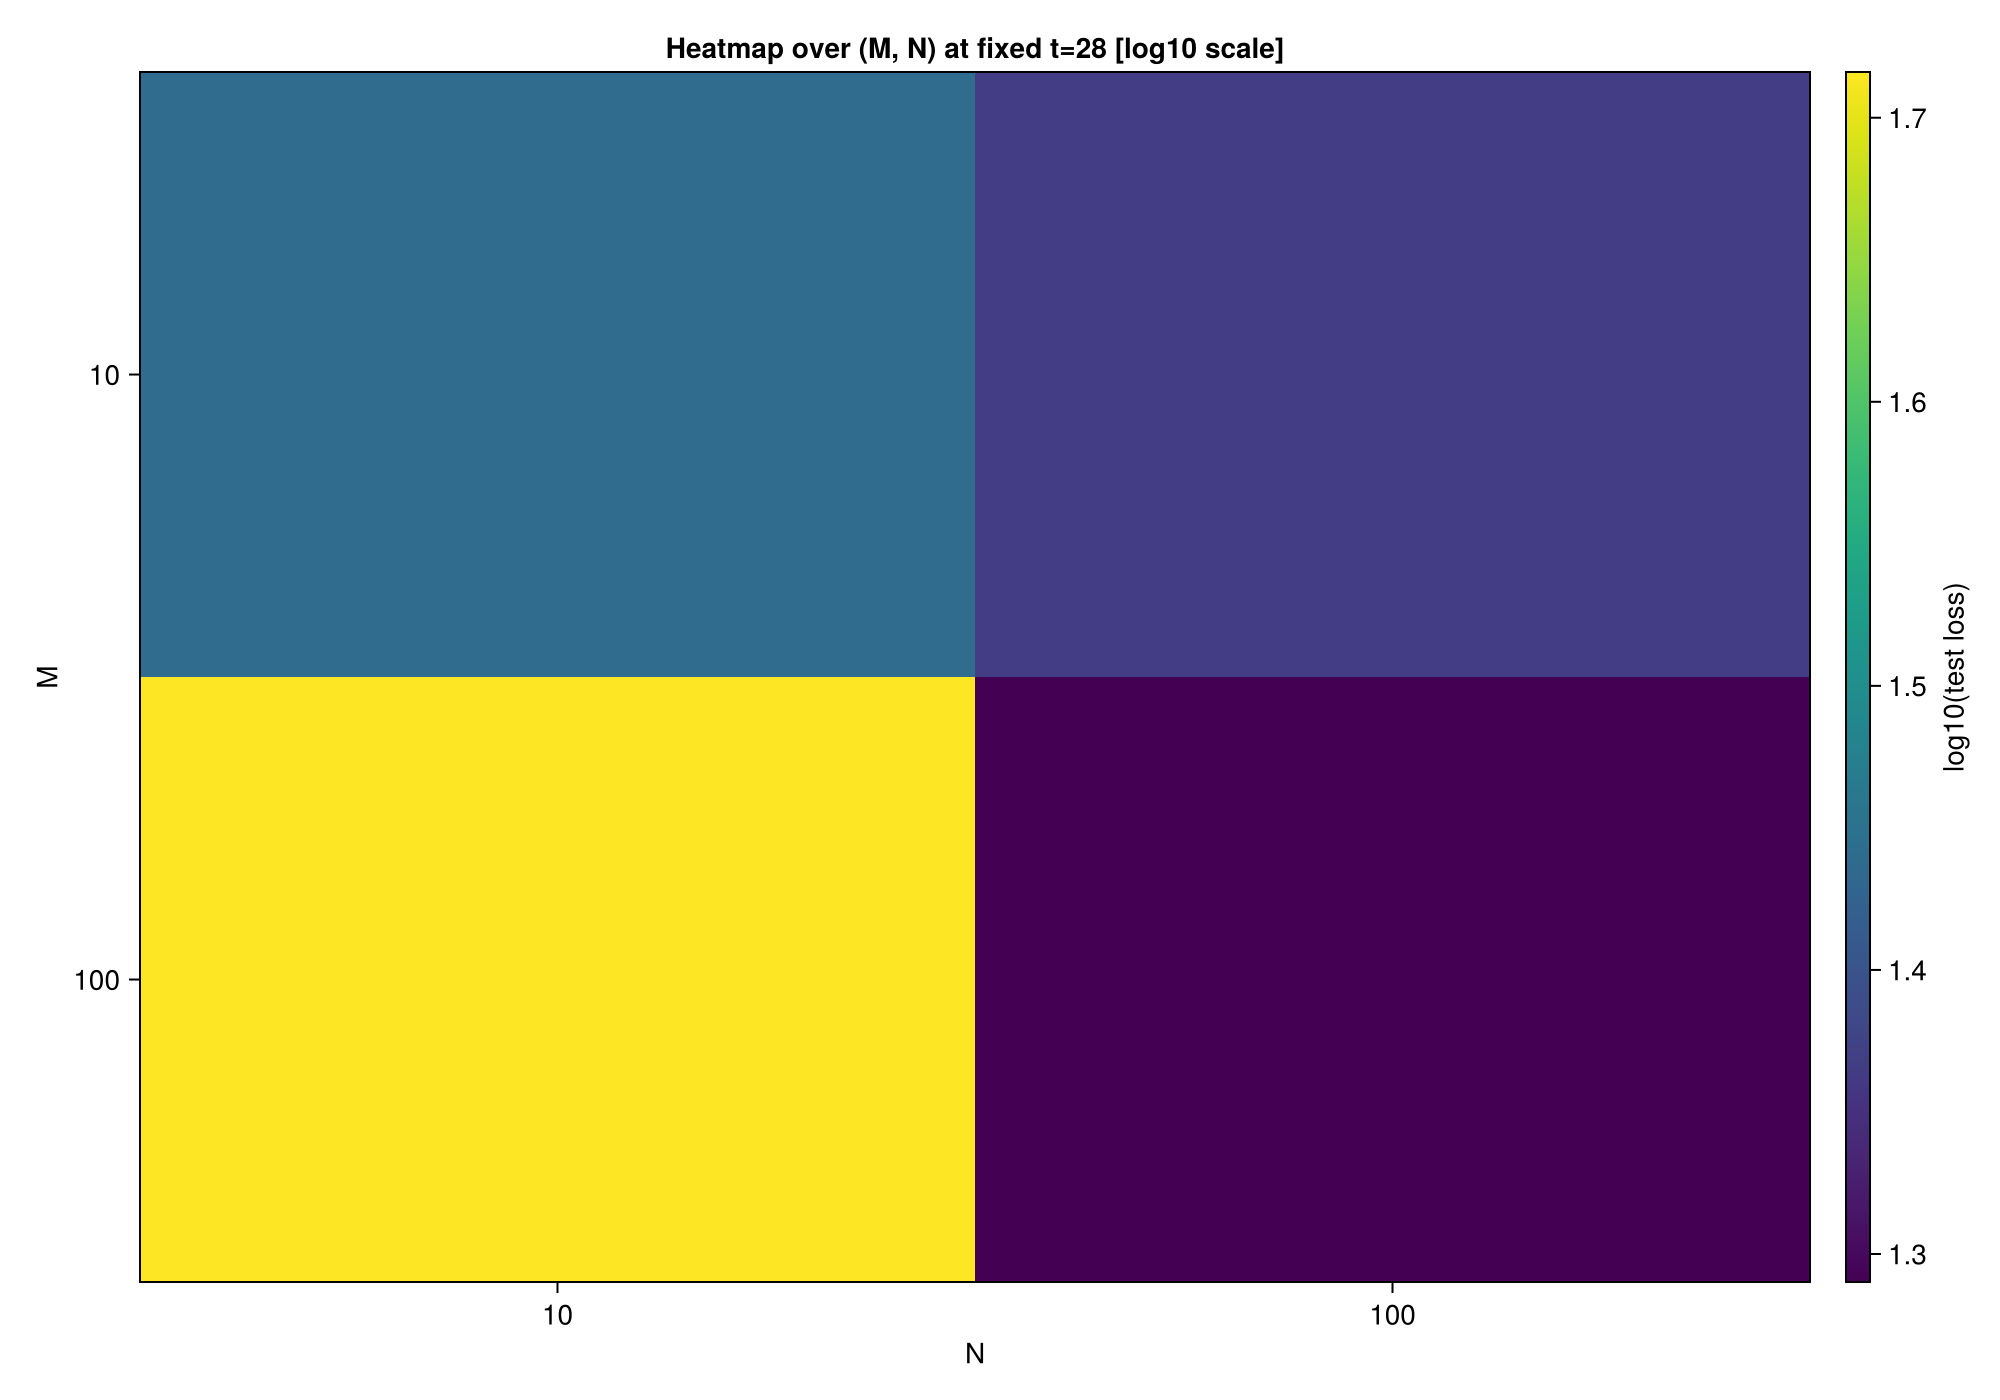

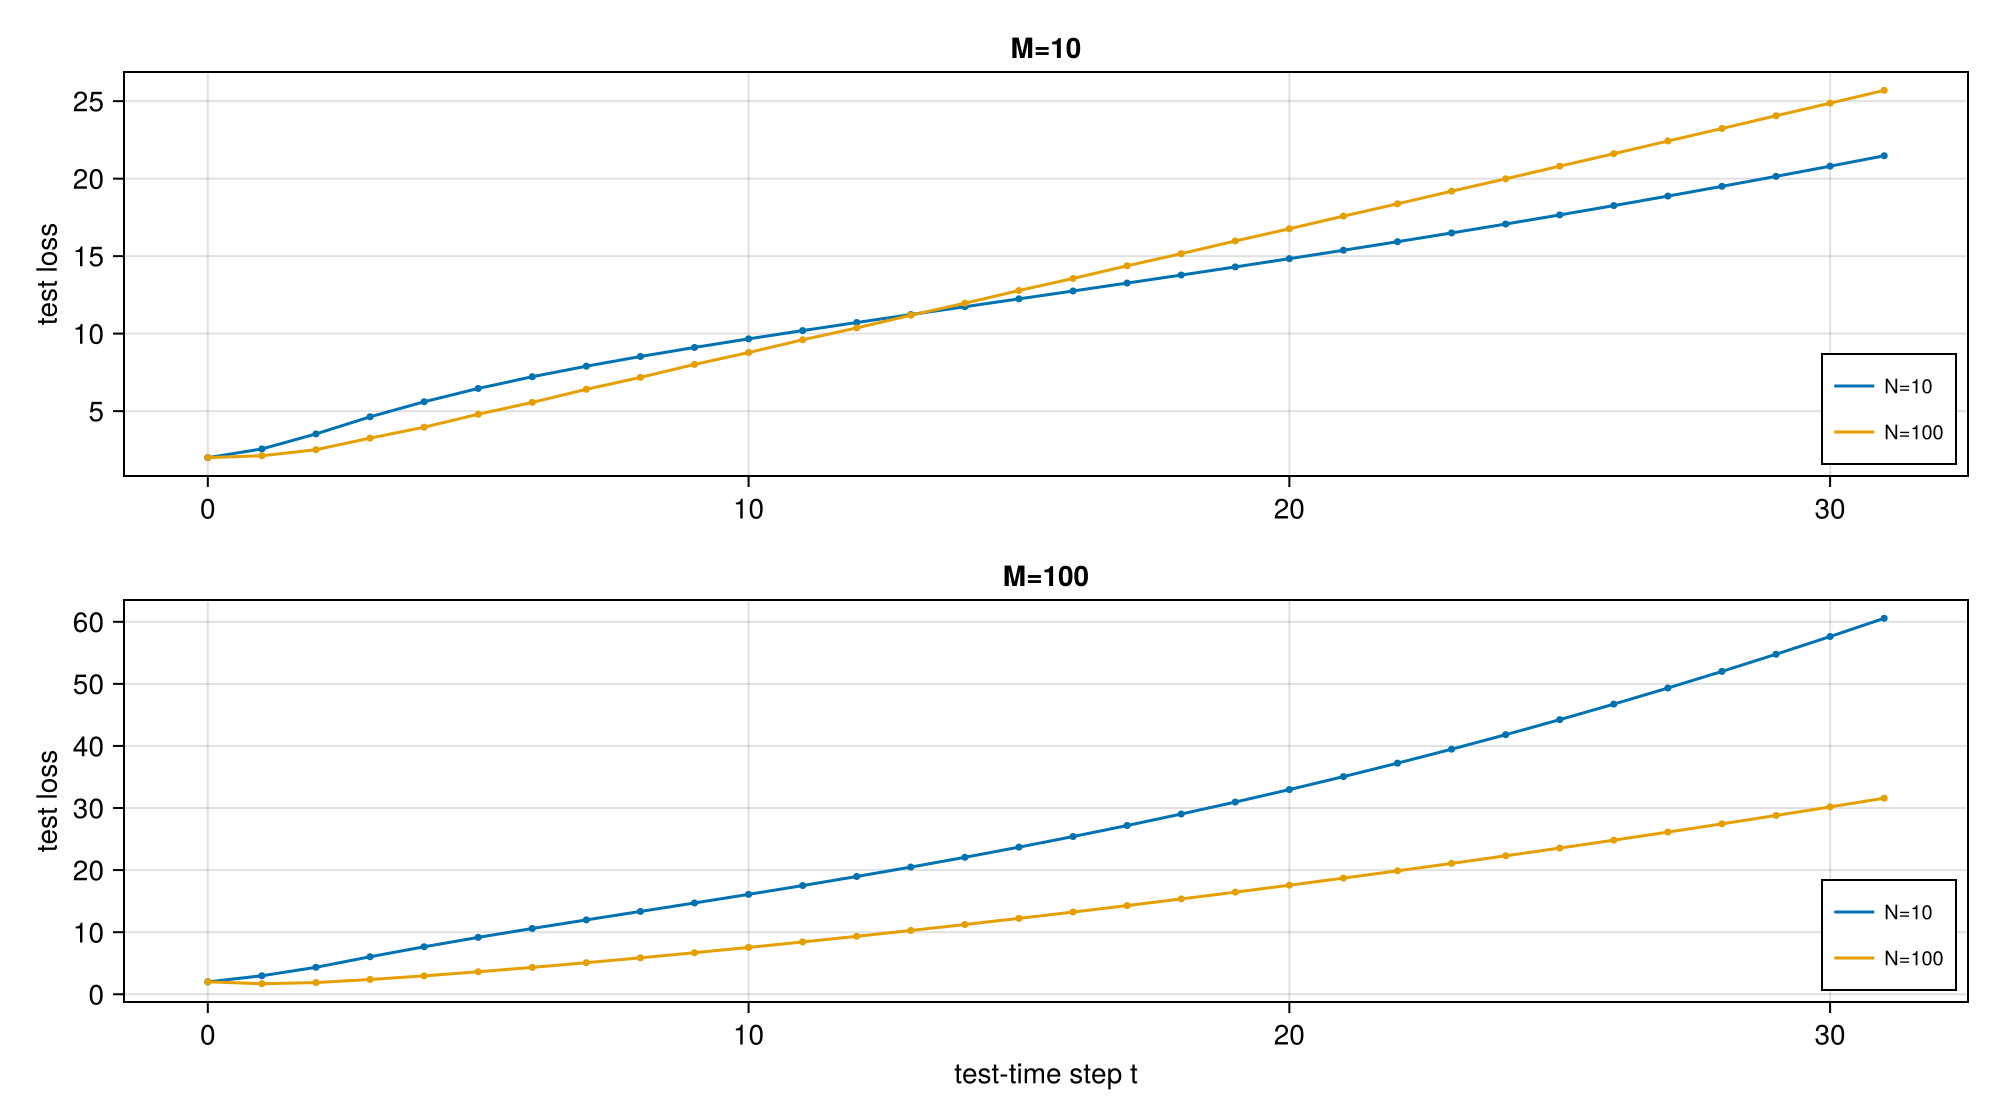

CairoMakie.Screen{IMAGE}


In [ ]:
using CairoMakie
using DelimitedFiles

outdir = "/home/takanami/cot_asymptotics/softmax_heatmap/results/softmax_heatmap_20260410_193854"

function read_vector_int(path::String)
    raw = readdlm(path, ',', Float64)
    return Int.(round.(vec(raw)))
end

function read_config(path::String)
    cfg = Dict{String,String}()
    for line in eachline(path)
        s = strip(line)
        isempty(s) && continue
        if occursin("=", s)
            k, v = split(s, "=", limit=2)
            cfg[strip(k)] = strip(v)
        end
    end
    return cfg
end

function main(outdir=outdir)
    base_dir = @__DIR__
    figdir = joinpath(outdir, "figures")
    mkpath(figdir)

    cfg = read_config(joinpath(outdir, "config.txt"))
    M_list = read_vector_int(joinpath(outdir, "M_list.csv"))
    N_list = read_vector_int(joinpath(outdir, "N_list.csv"))
    T_list = read_vector_int(joinpath(outdir, "EVAL_T_list.csv"))
    T_heat = parse(Int, get(cfg, "T_HEATMAP", string(T_list[end])))

    curves_long = readdlm(joinpath(outdir, "curves_long.csv"), ',', Float64)
    # columns: m, n, t, error

    heat_path = joinpath(outdir, "heat_t$(T_heat).csv")
    heat = readdlm(heat_path, ',', Float64)
    heat_l = log10.(max.(heat, 1e-12))
    # show larger M at top
    heat_log_plot = reverse(heat_log, dims = 1)
    M_labels_plot = reverse(M_list)

    # ---- Figure 1: Heatmap at fixed t ----
    fig1 = Figure(size = (1000, 700))
    ax1 = Axis(
        fig1[1, 1],
        xlabel = "N",
        ylabel = "M",
        title = "Heatmap over (M, N) at fixed t=$(T_heat) [log10 scale]",
    )
    hm = heatmap!(ax1, 1:length(N_list), 1:length(M_list), heat_log_plot, colormap = :viridis)
    ax1.xticks = (1:length(N_list), string.(N_list))
    ax1.yticks = (1:length(M_list), string.(M_labels_plot))
    Colorbar(fig1[1, 2], hm, label = "log10(test loss)")
    display(fig1)

    # ---- Figure 2: Curves grouped by M ----
    nrows = length(M_list)
    fig2 = Figure(size = (1000, 280 * nrows))
    for (i, m) in enumerate(M_list)
        ax = Axis(fig2[i, 1], ylabel = "test loss", title = "M=$(m)")
        for n in N_list
            mask = (curves_long[:, 1] .== m) .& (curves_long[:, 2] .== n)
            sub = curves_long[mask, :]
            if size(sub, 1) == 0
                continue
            end
            # sort by t
            p = sortperm(sub[:, 3])
            t = sub[p, 3]
            err = sub[p, 4]
            lines!(ax, t, err, label = "N=$(n)")
            scatter!(ax, t, err, markersize = 5)
        end
        axislegend(ax, position = :rb, labelsize = 10)
        if i == nrows
            ax.xlabel = "test-time step t"
        end
    end
    display(fig2)
end

main(outdir)